# Determinants of Foreign Direct Investment in West Africa

### A Panel Data Analysis
**Author:** Muhammed Lamin Janneh

**Research Question:**  

What economic factors are associated with Foreign Direct Investment (FDI)

in selected West African countries?

**Data Source:** World Bank World Development Indicators (WDI)

**Original sample:** 16 West African countries

##  Introduction

Foreign Direct Investment (FDI) is an important source of external

capital for developing economies. It can contribute to investment,

technology transfer, employment, and integration into international

markets.

This project investigates economic factors associated with FDI in

selected West African countries using panel-data econometric methods.

The analysis compares pooled OLS, country fixed effects, and

country-and-year fixed effects. Model diagnostics are also conducted

to assess multicollinearity and the reliability of statistical inference.

The analysis identifies statistical associations rather than proving

causal relationships.

##  Data

The data are obtained from the World Bank World Development Indicators.

The original dataset contains 16 West African countries covering

multiple years.

The dependent variable is Foreign Direct Investment (FDI), measured

as net inflows as a percentage of GDP.

The explanatory variables cover macroeconomic, demographic, labor,

trade, technology, investment, and structural characteristics.

## Import Relevant Librabries

In [9]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import wbdata
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

## World Bank Economic Indicators With Respective Countries

In [10]:
indicators = {"FP.CPI.TOTL.ZG": "Inflation",
              "SL.UEM.TOTL.ZS": "Unemployment","SP.POP.GROW":"Population_Growth",
              "BX.KLT.DINV.WD.GD.ZS":"FDI","NE.EXP.GNFS.ZS":"Exports","NE.IMP.GNFS.ZS":"Imports","NE.CON.GOVT.ZS":"Gov_Consumption",
              "SP.POP.DPND": "Dependency_ratio","SE.SEC.ENRR": "Secondary_education", "SE.PRM.ENRR": "Primary_education",
              "SL.AGR.EMPL.ZS": "Agriculture_Employment","SL.TLF.CACT.ZS":"Labor_Force_Participation", "NY.GDP.PCAP.CD":"GDP_PER_CAPITAL",
             "SP.URB.TOTL.IN.ZS":"Urban_Population_percentage_of_total_population",
             "PA.NUS.FCRF":"OFFICIAL EXCHANGE RATE LCU PER USD","NE.GDI.TOTL.ZS":"GROSS_CAPITAL FORMATION","NE.TRD.GNFS.ZS":"TRADE OPENESS",
             "GB.XPD.RSDV.GD.ZS":"RESEARCH AND DEVELOPMENT","NV.AGR.TOTL.ZG":"AGRICULTURE VALUE ADDED","NV.IND.TOTL.ZS":"INDUSTRY VALUE ADDED","NY.GDP.MKTP.KD.ZG":"GDP_Growth",
             "IT.NET.USER.ZS":"INTERNET_USAGE"}

countries = ["GMB", "SEN", "NGA", "GHA","BEN","BFA","CPV","CIV","GIN","GNB","LBR","MLI",
             "MRT","NER","SLE","TGO"]

## Load Data From World Bank Economic Indicators

In [11]:
df = wbdata.get_dataframe(indicators, country = countries)
df = df.reset_index()
df["year"] = pd.to_datetime(df["date"]).dt.year
df = df[(df["year"] >= 2000) & (df["year"] <= 2025)]
df = df.drop(columns = "date")
df

,country,Inflation,Unemployment,Population_Growth,FDI,Exports,Imports,Gov_Consumption,Dependency_ratio,Secondary_education,...,Urban_Population_percentage_of_total_population,OFFICIAL EXCHANGE RATE LCU PER USD,GROSS_CAPITAL FORMATION,TRADE OPENESS,RESEARCH AND DEVELOPMENT,AGRICULTURE VALUE ADDED,INDUSTRY VALUE ADDED,GDP_Growth,INTERNET_USAGE,year
40,Benin,4.165404,0.864,3.076653,-0.363491,20.605303,26.742849,8.080595,94.556102,20.000540,...,38.275952,710.207977,16.008402,47.348152,NaN,4.510035,18.756348,5.857714,0.225248,2000
41,Benin,3.984295,0.766,3.054355,0.456588,19.868579,28.388592,8.083390,93.796459,21.710440,...,38.618626,732.397693,17.752720,48.257171,NaN,6.379676,21.606306,5.333136,0.363418,2001
42,Benin,2.489162,0.690,3.040108,-0.462423,19.726611,24.041812,7.786333,93.042117,23.584669,...,39.003507,693.713226,14.833723,43.768423,NaN,2.464828,21.256065,4.643031,0.702946,2002
43,Benin,1.487242,0.747,3.049203,0.198870,18.644297,22.971933,8.828818,92.329889,24.900120,...,39.416970,579.897426,15.163790,41.616231,NaN,2.242303,21.765336,3.443577,0.951327,2003
44,Benin,0.873891,0.790,3.061731,-0.658689,18.513548,21.389427,8.809468,91.705874,26.704149,...,39.852570,527.338032,15.218605,39.902974,NaN,6.287293,20.499425,4.429685,1.182541,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1104,Togo,4.186215,2.344,2.378250,-1.594788,23.134296,33.243262,12.768227,77.235107,63.066937,...,42.310590,554.530675,21.504631,56.377558,NaN,NaN,20.021610,5.128901,30.338400,2021
1105,Togo,7.967574,1.965,2.352709,-2.004298,25.009210,36.565882,12.546287,76.467592,NaN,...,42.733233,623.759701,24.498281,61.575092,NaN,NaN,21.225708,6.294437,35.607498,2022
1106,Togo,5.489286,1.942,2.333455,0.812296,NaN,NaN,NaN,75.581224,63.419252,...,43.249685,606.569750,22.387985,59.929178,NaN,NaN,20.674719,6.192116,37.570202,2023
1107,Togo,2.862621,1.948,2.241367,0.786342,NaN,NaN,NaN,74.639712,NaN,...,43.814849,606.345298,NaN,NaN,0.22229,NaN,20.444605,6.532045,39.483200,2024


## Inspect Data

In [12]:
df.head(20).T

,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59
country,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin,Benin
Inflation,4.165404,3.984295,2.489162,1.487242,0.873891,5.364521,3.782177,1.298068,7.947299,0.896072,2.207835,2.704239,6.744683,0.428889,-0.548758,0.218786,-0.79331,0.043265,0.919171,0.732849
Unemployment,0.864,0.766,0.69,0.747,0.79,0.859,0.888,0.902,0.895,0.95,1.04,2.647,2.458,2.198,1.952,1.886,1.834,1.691,1.426,1.214
Population_Growth,3.076653,3.054355,3.040108,3.049203,3.061731,3.220612,3.120669,2.955096,3.019594,2.999036,2.984242,2.977822,2.967665,2.948852,2.955019,2.953916,2.924602,2.881179,2.813642,2.735388
FDI,-0.363491,0.456588,-0.462423,0.19887,-0.658689,-0.13382,-0.175765,1.70387,0.492563,-0.193122,0.561145,1.508441,2.527058,2.878637,3.05421,1.315012,1.114881,1.581705,1.360736,1.516208
Exports,20.605303,19.868579,19.726611,18.644297,18.513548,18.48364,18.057926,22.042853,22.14072,19.927967,23.072048,20.849652,23.896737,27.570565,31.430841,24.720451,27.606788,27.205595,27.274231,29.630527
Imports,26.742849,28.388592,24.041812,22.971933,21.389427,20.612291,21.716773,27.070931,25.634639,24.774662,28.358812,26.367377,26.84,31.629627,33.837434,32.035862,31.38014,34.271002,34.520964,34.050805
Gov_Consumption,8.080595,8.08339,7.786333,8.828818,8.809468,8.991074,9.666735,9.568485,10.233588,11.288621,11.211869,11.023542,11.128301,11.042234,10.180197,11.41138,10.280819,10.478984,10.410505,10.342063
Dependency_ratio,94.556102,93.796459,93.042117,92.329889,91.705874,90.972846,90.46407,90.214722,89.818484,89.202224,88.546696,88.062399,87.66222,87.335298,87.017212,86.690873,86.370312,85.997586,85.506996,84.877937
Secondary_education,20.00054,21.71044,23.584669,24.90012,26.704149,NaN,NaN,NaN,NaN,NaN,NaN,45.729469,NaN,52.037849,52.595268,55.133308,55.29459,NaN,NaN,NaN


In [13]:
df.columns

Index(['country', 'Inflation', 'Unemployment', 'Population_Growth', 'FDI',
       'Exports', 'Imports', 'Gov_Consumption', 'Dependency_ratio',
       'Secondary_education', 'Primary_education', 'Agriculture_Employment',
       'Labor_Force_Participation', 'GDP_PER_CAPITAL',
       'Urban_Population_percentage_of_total_population',
       'OFFICIAL EXCHANGE RATE LCU PER USD', 'GROSS_CAPITAL FORMATION',
       'TRADE OPENESS', 'RESEARCH AND DEVELOPMENT', 'AGRICULTURE VALUE ADDED',
       'INDUSTRY VALUE ADDED', 'GDP_Growth', 'INTERNET_USAGE', 'year'],
      dtype='object')

In [14]:
df.shape

(429, 24)

In [15]:
df.info()

<class 'wbdata.client.DataFrame'>
Index: 429 entries, 40 to 1108
Data columns (total 24 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   country                                          429 non-null    object 
 1   Inflation                                        386 non-null    float64
 2   Unemployment                                     416 non-null    float64
 3   Population_Growth                                400 non-null    float64
 4   FDI                                              399 non-null    float64
 5   Exports                                          348 non-null    float64
 6   Imports                                          348 non-null    float64
 7   Gov_Consumption                                  325 non-null    float64
 8   Dependency_ratio                                 400 non-null    float64
 9   Secondary_education                    

In [16]:
df["year"].max(), df["year"].min()

(np.int32(2025), np.int32(2000))

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inflation,386.0,6.272894,7.340965,-3.502586,1.452515,3.994905,8.720052,47.642873
Unemployment,416.0,4.576849,3.238100,0.316000,2.510500,3.570500,5.179250,14.650000
Population_Growth,400.0,2.582359,0.741353,0.013272,2.326040,2.569213,2.954192,5.905519
FDI,399.0,4.482486,9.315242,-11.191734,1.175418,2.406597,5.281785,103.337387
Exports,348.0,24.098203,9.654615,6.617335,17.820155,22.833766,29.675249,56.218633
Imports,348.0,35.509853,12.011356,12.577840,26.789920,32.532015,40.525606,82.467955
Gov_Consumption,325.0,12.959882,4.205960,4.765608,9.617314,13.230752,15.753997,26.587633
Dependency_ratio,400.0,85.701047,10.805411,47.941024,80.333981,86.447250,92.063825,107.779308
Secondary_education,235.0,41.018243,21.899797,6.231370,24.091115,38.148031,49.812204,107.027126
Primary_education,326.0,88.998507,21.474483,25.565756,74.892459,87.826140,103.166346,163.173555


## CHECK FOR MISSING VALUES

In [18]:
df.isnull().sum()

country                                              0
Inflation                                           43
Unemployment                                        13
Population_Growth                                   29
FDI                                                 30
Exports                                             81
Imports                                             81
Gov_Consumption                                    104
Dependency_ratio                                    29
Secondary_education                                194
Primary_education                                  103
Agriculture_Employment                              13
Labor_Force_Participation                           13
GDP_PER_CAPITAL                                     13
Urban_Population_percentage_of_total_population     13
OFFICIAL EXCHANGE RATE LCU PER USD                  24
GROSS_CAPITAL FORMATION                             75
TRADE OPENESS                                       68
RESEARCH A

## CHECKING THE MISSING VALUES OF DEPENDENT VARIABLE IN EACH COUNTRY

In [19]:
df.groupby("country")["FDI"].apply(lambda  x:  x.isnull().sum())

country
Benin             1
Burkina Faso      1
Cabo Verde        1
Cape Verde       13
Cote d'Ivoire     1
Gambia, The       1
Ghana             1
Guinea            2
Guinea-Bissau     1
Liberia           1
Mali              1
Mauritania        1
Niger             1
Nigeria           1
Senegal           1
Sierra Leone      1
Togo              1
Name: FDI, dtype: int64

## COPY THE ORIGINAL DATA FOR ANALYSIS
A replica of the original data is made as "df_model"in order to preserve our original data. Hence any data modification will be done on "df_model".

In [20]:
df_model = df.copy()

In [21]:
df_model

,country,Inflation,Unemployment,Population_Growth,FDI,Exports,Imports,Gov_Consumption,Dependency_ratio,Secondary_education,...,Urban_Population_percentage_of_total_population,OFFICIAL EXCHANGE RATE LCU PER USD,GROSS_CAPITAL FORMATION,TRADE OPENESS,RESEARCH AND DEVELOPMENT,AGRICULTURE VALUE ADDED,INDUSTRY VALUE ADDED,GDP_Growth,INTERNET_USAGE,year
40,Benin,4.165404,0.864,3.076653,-0.363491,20.605303,26.742849,8.080595,94.556102,20.000540,...,38.275952,710.207977,16.008402,47.348152,NaN,4.510035,18.756348,5.857714,0.225248,2000
41,Benin,3.984295,0.766,3.054355,0.456588,19.868579,28.388592,8.083390,93.796459,21.710440,...,38.618626,732.397693,17.752720,48.257171,NaN,6.379676,21.606306,5.333136,0.363418,2001
42,Benin,2.489162,0.690,3.040108,-0.462423,19.726611,24.041812,7.786333,93.042117,23.584669,...,39.003507,693.713226,14.833723,43.768423,NaN,2.464828,21.256065,4.643031,0.702946,2002
43,Benin,1.487242,0.747,3.049203,0.198870,18.644297,22.971933,8.828818,92.329889,24.900120,...,39.416970,579.897426,15.163790,41.616231,NaN,2.242303,21.765336,3.443577,0.951327,2003
44,Benin,0.873891,0.790,3.061731,-0.658689,18.513548,21.389427,8.809468,91.705874,26.704149,...,39.852570,527.338032,15.218605,39.902974,NaN,6.287293,20.499425,4.429685,1.182541,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1104,Togo,4.186215,2.344,2.378250,-1.594788,23.134296,33.243262,12.768227,77.235107,63.066937,...,42.310590,554.530675,21.504631,56.377558,NaN,NaN,20.021610,5.128901,30.338400,2021
1105,Togo,7.967574,1.965,2.352709,-2.004298,25.009210,36.565882,12.546287,76.467592,NaN,...,42.733233,623.759701,24.498281,61.575092,NaN,NaN,21.225708,6.294437,35.607498,2022
1106,Togo,5.489286,1.942,2.333455,0.812296,NaN,NaN,NaN,75.581224,63.419252,...,43.249685,606.569750,22.387985,59.929178,NaN,NaN,20.674719,6.192116,37.570202,2023
1107,Togo,2.862621,1.948,2.241367,0.786342,NaN,NaN,NaN,74.639712,NaN,...,43.814849,606.345298,NaN,NaN,0.22229,NaN,20.444605,6.532045,39.483200,2024


## 4. Data Cleaning

The data are checked for missing observations and variables are converted

to appropriate numerical formats.

Because panel estimation requires the dependent and explanatory

variables to correspond to the same observations, observations with

missing values in the variables required for a particular model are

removed before estimation.

In [22]:
df_model.columns = (df_model.columns.str.lower()
                            .str.strip()
                            .str.replace(" ", "_"))

In [23]:
df_model.dtypes

country                                             object
inflation                                          float64
unemployment                                       float64
population_growth                                  float64
fdi                                                float64
exports                                            float64
imports                                            float64
gov_consumption                                    float64
dependency_ratio                                   float64
secondary_education                                float64
primary_education                                  float64
agriculture_employment                             float64
labor_force_participation                          float64
gdp_per_capital                                    float64
urban_population_percentage_of_total_population    float64
official_exchange_rate_lcu_per_usd                 float64
gross_capital_formation                            float

In [24]:
df_model = df_model.sort_values(by = ["year","country"]).reset_index(drop = True)

In [25]:
df_model["country"] = df_model["country"].astype("category")

In [26]:
df_model = df_model.dropna(subset = ["fdi"])

In [27]:
df_model.shape

(399, 24)

##  Descriptive Statistics

Descriptive statistics are examined before estimation to understand

the distribution and variation of the variables.

In [28]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
inflation,385.0,6.250095,7.336822,-3.502586,1.450691,3.984295,8.694828,47.642873
unemployment,399.0,4.598784,3.248705,0.316000,2.493000,3.656000,5.200500,14.650000
population_growth,399.0,2.582668,0.742259,0.013272,2.324958,2.570460,2.954468,5.905519
fdi,399.0,4.482486,9.315242,-11.191734,1.175418,2.406597,5.281785,103.337387
exports,347.0,24.080212,9.662713,6.617335,17.814127,22.718440,29.553623,56.218633
imports,347.0,35.487676,12.021564,12.577840,26.774294,32.516719,40.143631,82.467955
gov_consumption,324.0,12.961091,4.212409,4.765608,9.612817,13.238177,15.755820,26.587633
dependency_ratio,399.0,85.683283,10.813128,47.941024,80.304789,86.446129,91.990145,107.779308
secondary_education,235.0,41.018243,21.899797,6.231370,24.091115,38.148031,49.812204,107.027126
primary_education,324.0,88.973665,21.530637,25.565756,74.713352,87.826140,103.266924,163.173555


In [29]:
warnings.filterwarnings("ignore", category=FutureWarning)

## FDI SUMMARY BY COUNTRY

In [30]:
summary = df_model.groupby("country")["fdi"].agg(["max","min","mean","sum"])
summary

,max,min,mean,sum
country,,,,
Benin,3.054210,-0.658689,1.131399,28.284987
Burkina Faso,3.647668,-0.557280,1.092077,27.301925
Cabo Verde,11.876432,1.600131,6.205685,155.142131
Cape Verde,NaN,NaN,NaN,0.000000
Cote d'Ivoire,3.583467,0.778244,1.451760,36.294000
"Gambia, The",12.502620,1.871884,5.740514,143.512848
Ghana,9.466439,0.955694,4.519858,112.996461
Guinea,18.828009,-0.840221,3.728468,89.483225
Guinea-Bissau,4.489253,0.095881,1.505574,37.639341


## Visualization

CORRELATION HEATMAP

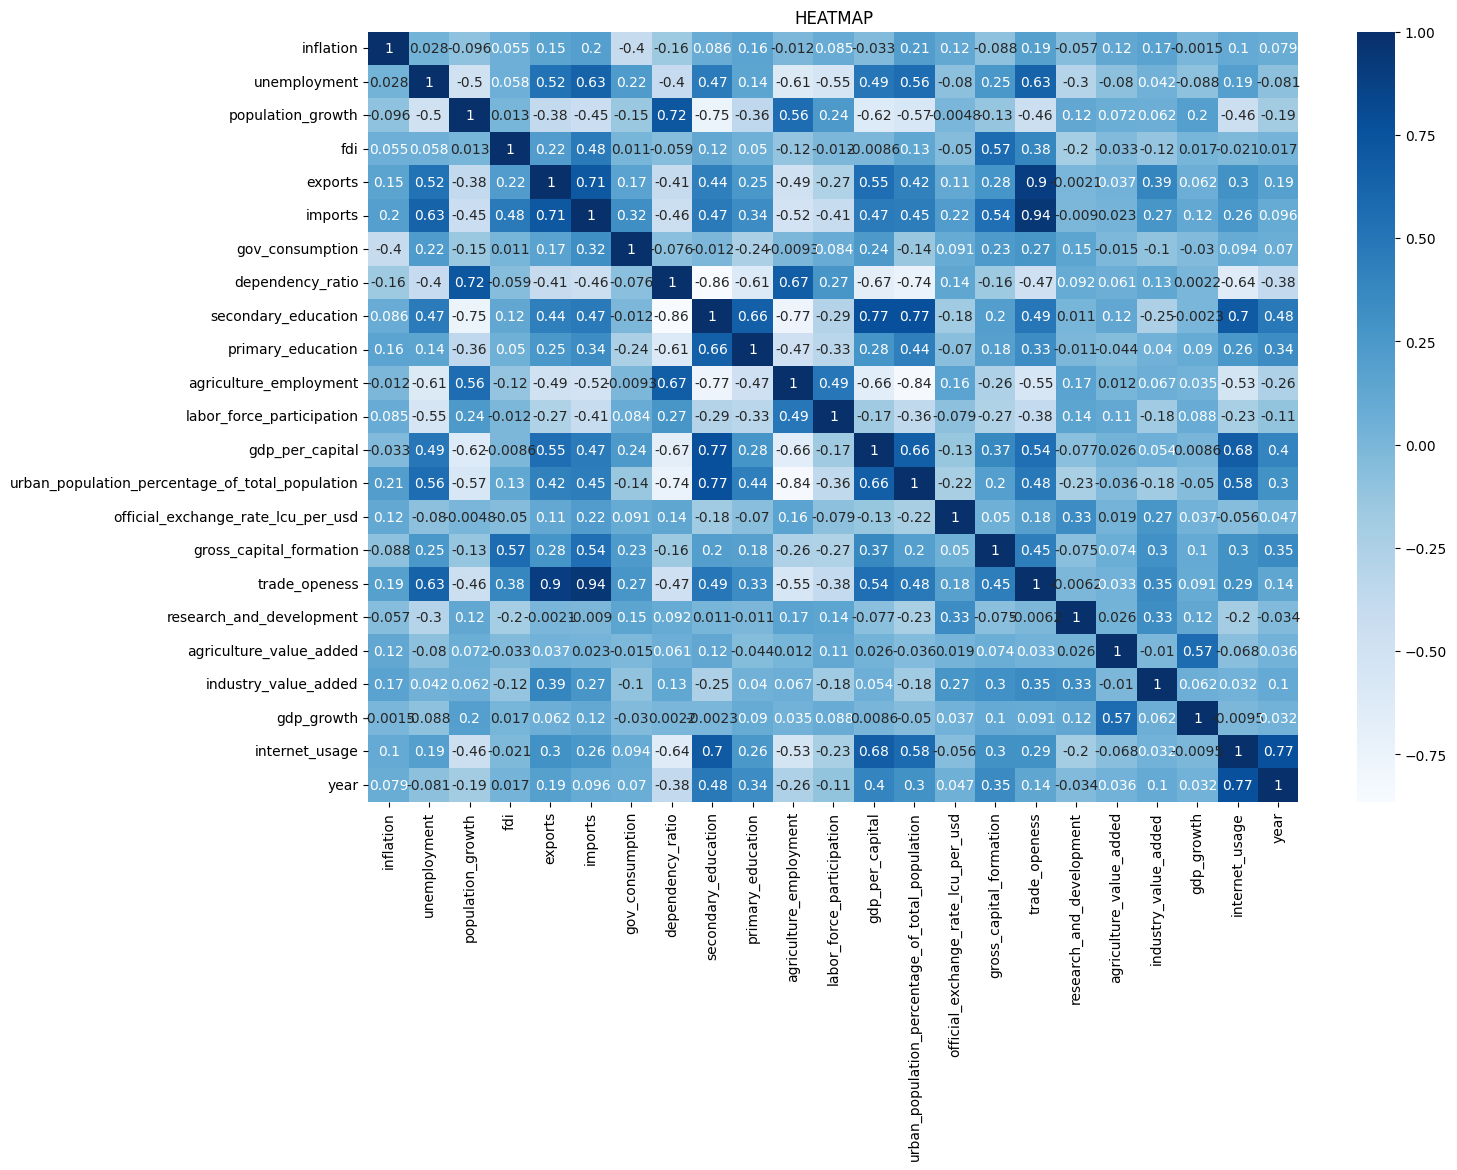

In [33]:
corr = df_model.corr(numeric_only=True)
plt.figure(figsize = (15,10))
sns.heatmap(corr,
            annot = True,
           cmap = "Blues")
plt.title("HEATMAP")
plt.show()

KERNEL DENSITY PLOT

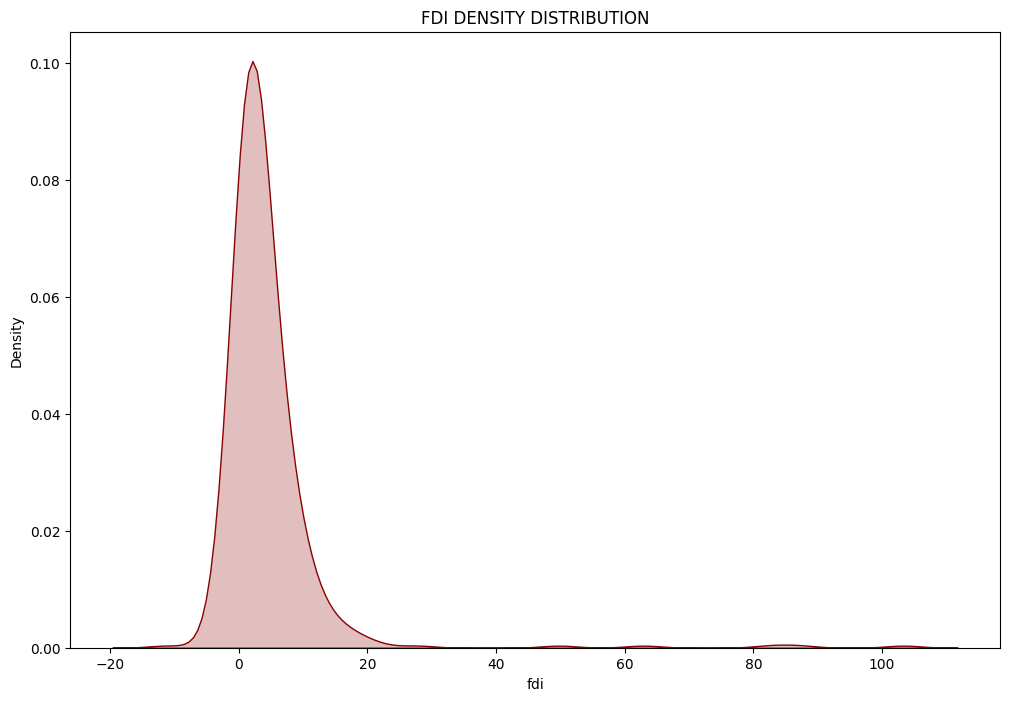

In [34]:
plt.figure(figsize =(12,8))
sns.kdeplot(data = df_model,
            x = "fdi",
            fill = True,
            color = "darkred")
plt.title("FDI DENSITY DISTRIBUTION")
plt.show()

LINE PLOT

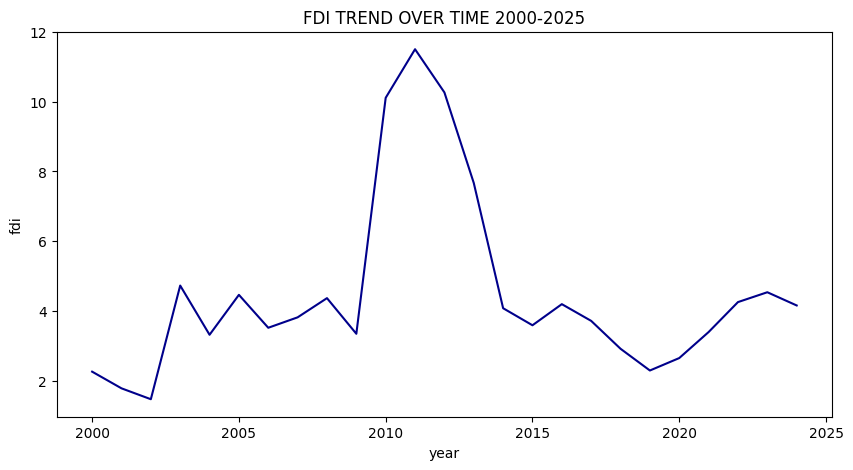

In [35]:
plt.figure(figsize = (10,5))
sns.lineplot(data = df_model,
             x = "year",
             y = "fdi",
             errorbar=None,
            color = "darkblue")
plt.title("FDI TREND OVER TIME 2000-2025",fontsize = 12)
plt.show()

REGRESSION PLOTS:

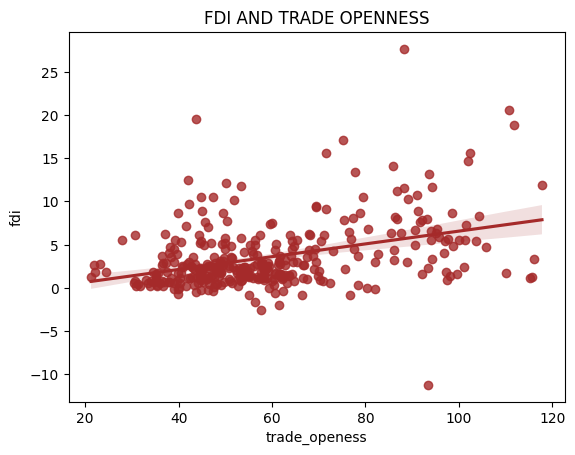

In [36]:
sns.regplot(data = df_model,
                x = "trade_openess",
                y = "fdi",
           color = "brown")
plt.title("FDI AND TRADE OPENNESS")
plt.show()

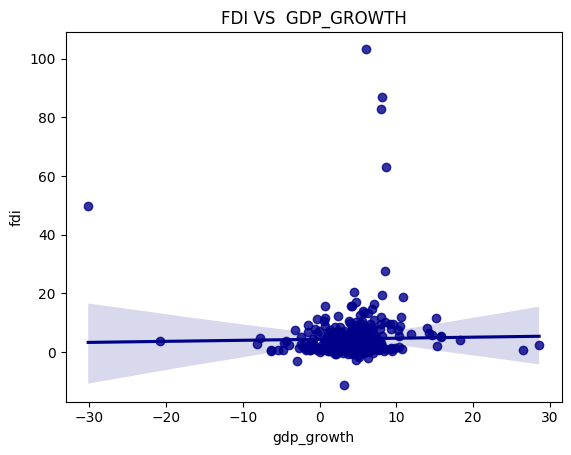

In [37]:
sns.regplot(data = df_model,
            x = "gdp_growth",
            y = "fdi",
           color = "darkblue")
plt.title("FDI VS  GDP_GROWTH")
plt.show()

BARPLOT

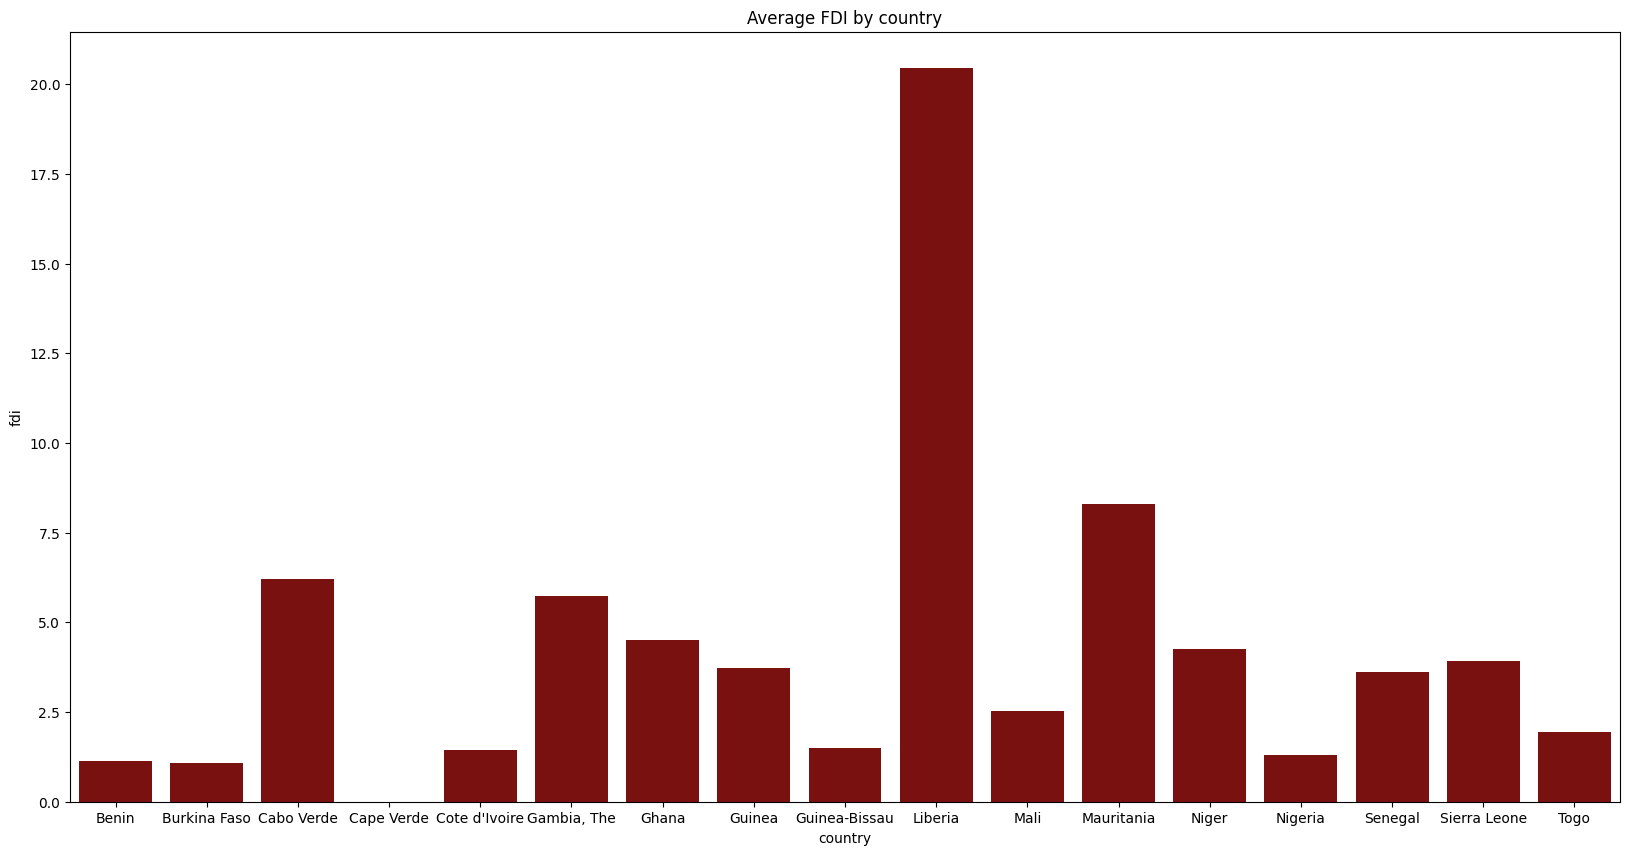

In [38]:
plt.figure(figsize = (20,10))
sns.barplot(data = df_model,
            x = "country",
            y = "fdi",
            errorbar=None,
           color = "darkred",
           estimator = "mean")
plt.title("Average FDI by country")
plt.show()

In [39]:
df_model["year"] = df_model["year"].astype("category")

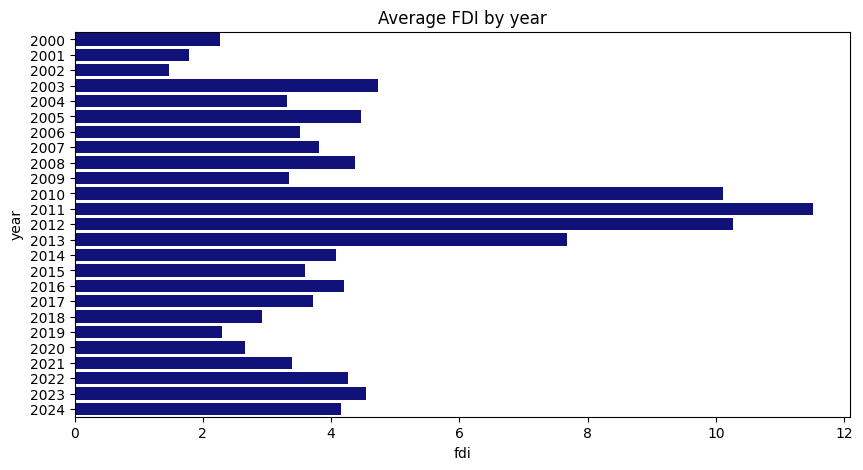

In [40]:
plt.figure(figsize = (10,5))
sns.barplot(data = df_model,
            x = "fdi",
            y = "year",
            errorbar=None,
           color = "darkblue",
           estimator = "mean")
plt.title("Average FDI by year")
plt.show()

SCATTER PLOT

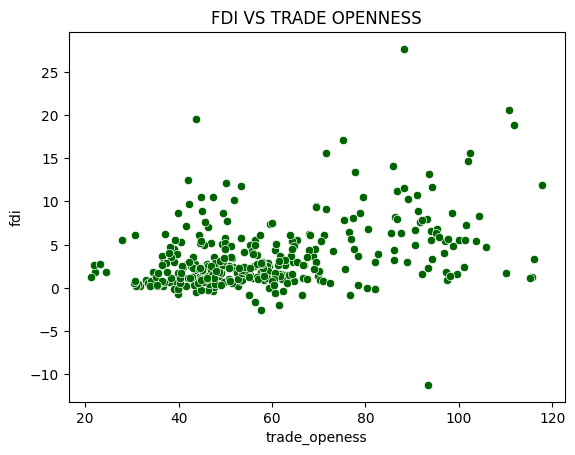

In [41]:
sns.scatterplot(data = df_model,
            x = "trade_openess",
            y = "fdi",
               color = "darkgreen")
plt.title("FDI VS TRADE OPENNESS")
plt.show()

### Interpretation

The visualizations provide descriptive evidence about the relationships

between FDI and selected explanatory variables. The fitted lines show

the direction of the raw linear association but do not control for other

variables or country-specific characteristics. Therefore, the graphs

are not interpreted as causal evidence.

In [42]:
df_model.columns

Index(['country', 'inflation', 'unemployment', 'population_growth', 'fdi',
       'exports', 'imports', 'gov_consumption', 'dependency_ratio',
       'secondary_education', 'primary_education', 'agriculture_employment',
       'labor_force_participation', 'gdp_per_capital',
       'urban_population_percentage_of_total_population',
       'official_exchange_rate_lcu_per_usd', 'gross_capital_formation',
       'trade_openess', 'research_and_development', 'agriculture_value_added',
       'industry_value_added', 'gdp_growth', 'internet_usage', 'year'],
      dtype='object')

##  Initial 18-Variable FDI Model

The initial specification includes a broad set of economic and

structural variables that may theoretically be associated with FDI.

The purpose of this specification is to examine the explanatory power

of a comprehensive model before conducting diagnostic tests.

POOLED OLS 

In [43]:
df_model["year"] = df_model["year"].astype(int)

In [44]:
data = df_model[['country','inflation','agriculture_value_added','gross_capital_formation', 'unemployment', 'gdp_growth',
       'population_growth', 'fdi','trade_openess','industry_value_added','gov_consumption',
       'dependency_ratio', 'secondary_education', 'primary_education',
       'agriculture_employment', 'labor_force_participation',
       'gdp_per_capital', 'urban_population_percentage_of_total_population',
       'official_exchange_rate_lcu_per_usd', 'year',"internet_usage"]].dropna()

data = data.set_index(["country","year"])
X = data[['inflation', 'unemployment',
       'population_growth', 'gdp_growth','internet_usage','gov_consumption','gross_capital_formation',
       'dependency_ratio', 'secondary_education', 'primary_education',
       'agriculture_employment', 'labor_force_participation','agriculture_value_added',
       'gdp_per_capital', 'urban_population_percentage_of_total_population','trade_openess','industry_value_added',
       'official_exchange_rate_lcu_per_usd']]
X = sm.add_constant(X)
Y = data["fdi"]

pool_model = sm.OLS(Y,X).fit()
pool_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    fdi   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     8.258
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           3.85e-08
Time:                        17:16:41   Log-Likelihood:                -116.42
No. Observations:                  56   AIC:                             270.8
Df Residuals:                      37   BIC:                             309.3
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===================================================================================================================
                                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
const                                             -19.5819     34.327     -0.570      0.572     -89.136      49.972
inflation                                           0.2027      0.138      1.467      0.151      -0.077       0.483
unemployment                                        0.2796      0.247      1.132      0.265      -0.221       0.780
population_growth                                  -2.7801      2.231     -1.246      0.221      -7.301       1.741
gdp_growth                                          0.1280      0.118      1.085      0.285      -0.111       0.367
internet_usage                                     -0.5205      0.543     -0.958      0.344      -1.621       0.580
gov_consumption                                     0.7743      0.194      3.987      0.000       0.381       1.168
gross_capital_formation                             0.4465      0.082      5.446      0.000       0.280       0.613
dependency_ratio                                    0.0143      0.226      0.063      0.950      -0.443       0.472
secondary_education                                 0.2145      0.110      1.953      0.058      -0.008       0.437
primary_education                                  -0.0817      0.081     -1.011      0.319      -0.246       0.082
agriculture_employment                             -0.2546      0.170     -1.495      0.143      -0.600       0.091
labor_force_participation                           0.3318      0.109      3.045      0.004       0.111       0.553
agriculture_value_added                            -0.0358      0.052     -0.694      0.492      -0.140       0.069
gdp_per_capital                                    -0.0022      0.004     -0.556      0.582      -0.010       0.006
urban_population_percentage_of_total_population     0.0466      0.195      0.239      0.812      -0.348       0.441
trade_openess                                       0.1451      0.089      1.636      0.110      -0.035       0.325
industry_value_added                               -0.2182      0.164     -1.328      0.192      -0.551       0.115
official_exchange_rate_lcu_per_usd               -4.62e-06      0.001     -0.007      0.995      -0.001       0.001
==============================================================================
Omnibus:                        0.329   Durbin-Watson:                   1.808
Prob(Omnibus):                  0.848   Jarque-Bera (JB):                0.276
Skew:                           0.161   Prob(JB):                        0.871
Kurtosis:                       2.881   Cond. No.                     1.63e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance ma

PUTIING FIXED EFFFECT AND TIME EFFECTS INTO ACCOUNT IN OUR INITIAL MODEL

In [45]:
from linearmodels.panel import PanelOLS

MODEL WITH FIXED EFFECT AND CLUSTERED STANDARD ERROR

In [46]:
fe_model1 = PanelOLS(Y,X,entity_effects = True).fit(cov_type = "clustered",
                                                   cluster_entity = True)
fe_model1.summary

Dep. Variable:,fdi,R-squared:,0.7991
Estimator:,PanelOLS,R-squared (Between):,-14.922
No. Observations:,56,R-squared (Within):,0.7991
Date:,"Thu, Aug 27 2026",R-squared (Overall):,-2.1858
Time:,17:16:44,Log-likelihood,-107.43
Cov. Estimator:,Clustered,,
,,F-statistic:,6.4084
Entities:,9,P-value,0.0000
Avg Obs:,6.2222,Distribution:,"F(18,29)"
Min Obs:,3.0000,,
Max Obs:,10.0000,F-statistic (robust):,-5.189e+14


### Initial Model Results

The initial fixed-effects model produces a within R-squared of

approximately **0.7991**.

This indicates that the model explains a large proportion of the

within-country variation in FDI in the estimation sample.

However, a high R-squared alone does not establish that the model is

well specified. Diagnostic tests are therefore required before using

the model for substantive conclusions.

MODEL DIAGNOSTICS

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

##  Multicollinearity Diagnostic

Variance Inflation Factors (VIF) are used to assess multicollinearity

among the explanatory variables.

Multicollinearity occurs when explanatory variables contain substantial

overlapping information. High multicollinearity can make coefficient

estimates unstable and increase standard errors.

In [48]:
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values,i)
              for i in range(X.shape[1])]
vif.sort_values(by = "VIF", ascending = False)

,Variable,VIF
0,const,11647.548502
11,agriculture_employment,48.528502
15,urban_population_percentage_of_total_population,42.012158
10,primary_education,29.773420
14,gdp_per_capital,23.298724
16,trade_openess,21.831523
12,labor_force_participation,18.756656
5,internet_usage,18.253340
8,dependency_ratio,17.182907
9,secondary_education,16.566562


### Interpretation

The initial 18-variable specification contains substantial

multicollinearity, with several explanatory variables having very high

VIF values.

This is a concern because the large number of closely related economic

variables may make it difficult to separately identify their individual

relationships with FDI.

Therefore, the initial model is not selected solely on the basis of

its high R-squared

REDUCED FDI MODEL


Following the diagnostic analysis, a more parsimonious specification

is estimated.

The reduced model retains variables with clear economic motivation

while reducing the degree of multicollinearity and the number of

parameters relative to the small estimation sample.

The reduced specification includes:

- Inflation

- Trade openness

- Gross capital formation

- Internet usage

- Labor-force participation

- Population growth

- Official exchange rate

- GDP growth

In [49]:
df_model.columns

Index(['country', 'inflation', 'unemployment', 'population_growth', 'fdi',
       'exports', 'imports', 'gov_consumption', 'dependency_ratio',
       'secondary_education', 'primary_education', 'agriculture_employment',
       'labor_force_participation', 'gdp_per_capital',
       'urban_population_percentage_of_total_population',
       'official_exchange_rate_lcu_per_usd', 'gross_capital_formation',
       'trade_openess', 'research_and_development', 'agriculture_value_added',
       'industry_value_added', 'gdp_growth', 'internet_usage', 'year'],
      dtype='object')

REDUCED POOL OLS MODEL

In [50]:
x = data[["inflation","trade_openess","gross_capital_formation","internet_usage","labor_force_participation",
    "population_growth","official_exchange_rate_lcu_per_usd","gdp_growth"]]
x = sm.add_constant(x)
y = data["fdi"]

pool = sm.OLS(y,x).fit()
pool.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    fdi   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     4.985
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           0.000166
Time:                        17:17:04   Log-Likelihood:                -144.38
No. Observations:                  56   AIC:                             306.8
Df Residuals:                      47   BIC:                             325.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -6.2682      5.950     -1.053      0.298     -18.238       5.702
inflation                              0.1242      0.120      1.033      0.307      -0.118       0.366
trade_openess                          0.1074      0.061      1.764      0.084      -0.015       0.230
gross_capital_formation                0.1354      0.089      1.518      0.136      -0.044       0.315
internet_usage                        -0.0241      0.240     -0.100      0.920      -0.507       0.459
labor_force_participation              0.0230      0.098      0.236      0.814      -0.173       0.219
population_growth                     -0.6791      2.098     -0.324      0.748      -4.900       3.542
official_exchange_rate_lcu_per_usd    -0.0003      0.001     -0.367      0.715      -0.002       0.001
gdp_growth                             0.2027      0.131      1.548      0.128      -0.061       0.466
==============================================================================
Omnibus:                       42.504   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              183.781
Skew:                           1.983   Prob(JB):                     1.24e-40
Kurtosis:                      10.939   Cond. No.                     1.87e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.87e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Result

The reduced pooled OLS model has an R-squared of approximately 0.459.

Although the model is statistically significant overall, pooled OLS

may be inappropriate if unobserved country characteristics are

correlated with the explanatory variables.

COUNTRY FIXED EFFECTS

##  Country Fixed Effects

The country fixed-effects model controls for unobserved characteristics

that are constant within each country over time.

The model therefore focuses on within-country variation.

In [51]:
fe_models2 = PanelOLS(y,
                    x,
                   entity_effects = True).fit()
fe_models2.summary

Dep. Variable:,fdi,R-squared:,0.4788
Estimator:,PanelOLS,R-squared (Between):,-55.445
No. Observations:,56,R-squared (Within):,0.4788
Date:,"Thu, Aug 27 2026",R-squared (Overall):,-14.040
Time:,17:17:15,Log-likelihood,-134.12
Cov. Estimator:,Unadjusted,,
,,F-statistic:,4.4793
Entities:,9,P-value,0.0006
Avg Obs:,6.2222,Distribution:,"F(8,39)"
Min Obs:,3.0000,,
Max Obs:,10.0000,F-statistic (robust):,4.4793


### Result

The country fixed-effects model has a within R-squared of 0.4788.

The poolability test has a p-value of 0.0529. This is slightly above

the 5% significance level, providing borderline evidence against the

pooled specification.

Given the panel structure and the possibility of persistent

country-specific characteristics, the country fixed-effects model is

retained as the main specificcation.

##  Country and Year Fixed Effects

The two-way fixed-effects model controls for both country-specific

effects and year-specific effects.

Country effects capture persistent differences between countries,

while year effects capture shocks common across countries in a given

year.

In [52]:
fe_models2 = PanelOLS(y,
                    x,
                   entity_effects = True,
                     time_effects = True).fit()
fe_models2.summary

Dep. Variable:,fdi,R-squared:,0.5478
Estimator:,PanelOLS,R-squared (Between):,-54.367
No. Observations:,56,R-squared (Within):,-0.3542
Date:,"Thu, Aug 27 2026",R-squared (Overall):,-13.222
Time:,17:17:17,Log-likelihood,-119.41
Cov. Estimator:,Unadjusted,,
,,F-statistic:,4.2396
Entities:,9,P-value,0.0020
Avg Obs:,6.2222,Distribution:,"F(8,28)"
Min Obs:,3.0000,,
Max Obs:,10.0000,F-statistic (robust):,4.2396


### Result

The two-way fixed-effects model rejects poolability at the 5% level.

However, the within R-squared is negative (-0.3542), indicating poor

within-sample explanatory performance relative to the fixed-effects

benchmark.

Given the small sample and the large number of fixed effects relative

to available observations, the country fixed-effects specification is

retained as the primary model.

##  Clustered Standard Errors

The main country fixed-effects model is estimated using standard errors

clustered at the country level.

Clustering allows observations within the same country to have

correlated errors over time and provides more robust inference.

The clustered results are therefore used when interpreting statistical

significance.

In [53]:
fe_models3 = PanelOLS(y,
                    x,
                   entity_effects = True).fit(cov_type = "clustered",
                                             cluster_entity = True)
fe_models3.summary

Dep. Variable:,fdi,R-squared:,0.4788
Estimator:,PanelOLS,R-squared (Between):,-55.445
No. Observations:,56,R-squared (Within):,0.4788
Date:,"Thu, Aug 27 2026",R-squared (Overall):,-14.040
Time:,17:17:20,Log-likelihood,-134.12
Cov. Estimator:,Clustered,,
,,F-statistic:,4.4793
Entities:,9,P-value,0.0006
Avg Obs:,6.2222,Distribution:,"F(8,39)"
Min Obs:,3.0000,,
Max Obs:,10.0000,F-statistic (robust):,368.20


##  Main Findings

The final country fixed-effects model with country-clustered standard

errors produces the following main findings:

### Population Growth

Coefficient: **-11.040**  

p-value: **0.0016**

Population growth has a statistically significant negative association

with FDI.

### Trade Openness

Coefficient: **0.2354**  

p-value: **0.0550**

Trade openness has a positive coefficient and provides borderline

evidence of a positive association with FDI at the 10% significance level.

### Other Variables

Inflation, gross capital formation, internet usage, labor-force

participation, exchange rate, and GDP growth are not statistically

significant at the 5% level in the clustered country fixed-effects model.

Statistical insignificance should not be interpreted as proof that these

variables have no effect in reality.

## MODEL DIAGNOSTICS 

VARIANCE INFLATION FACTOR

In [55]:
VIF = pd.DataFrame()
VIF["Variable"] = x.columns
VIF["VIF"] =[variance_inflation_factor(x.values,i)
              for i in range(x.shape[1])]
VIF.sort_values(by = "VIF", ascending = False)

,Variable,VIF
0,const,163.765661
5,labor_force_participation,7.040560
2,trade_openess,4.817025
7,official_exchange_rate_lcu_per_usd,3.664831
1,inflation,3.310798
6,population_growth,3.180085
3,gross_capital_formation,2.151854
4,internet_usage,1.668820
8,gdp_growth,1.052525


## Model Diagnostics:

## Multicollinearity — VIF

Variance Inflation Factors (VIF) are used to check whether the explanatory variables are highly correlated with one another.

The reduced model has substantially lower VIF values than the initial 18-variable model. The highest VIF among the explanatory variables is 7.04 for labor-force participation.

## Heteroskedasticity

Heteroskedasticity occurs when the variance of the regression errors is not constant across observations.

The model uses country-clustered standard errors, which provide inference that is robust to heteroskedasticity and allow errors to be correlated within countries over time.

## Serial Correlation

Serial correlation occurs when regression errors are correlated over time within a country.

Because the data contain repeated observations for the same countries, serial correlation is a potential concern in the panel model.

Country-clustered standard errors allow for within-country correlation over time, making the statistical inference more robust to this problem.

##  Diagnostic Conclusion

Overall, the reduced model has substantially improved multicollinearity compared with the initial 18-variable specification.

The final estimates use country-clustered standard errors to provide more robust statistical inference in the presence of heteroskedasticity and within-country serial correlation.

# MODEL COMPARISON

In [56]:
comparison = pd.DataFrame({"MODEL":["Pooled OLS","Reduced Country Fixed Effects","Reduced Country + Year + Fixed Effects","Initial 18-variables FE"],
                           "R^2/Within r^2": [0.459,0.4788,-0.3542,0.7991],
                           "F-Statistics": [4.983,4.479,4.2396,6.4084],
                           "P-value":[0.000166,0.0006,0.0020,0.0000]})
comparison
                           

,MODEL,R^2/Within r^2,F-Statistics,P-value
0,Pooled OLS,0.4590,4.9830,0.000166
1,Reduced Country Fixed Effects,0.4788,4.4790,0.000600
2,Reduced Country + Year + Fixed Effects,-0.3542,4.2396,0.002000
3,Initial 18-variables FE,0.7991,6.4084,0.000000


## Interpretation
The initial 18-variable model has the highest R-squared, but it also

has substantial multicollinearity and a much larger number of

parameters relative to the available observations.

Therefore, R-squared is not used as the sole criterion for model selection.

The reduced country fixed-effects model with clustered standard errors

is used as the main specification.

## Limitations

- The final estimation sample is relatively small.

- The number of country clusters is limited.

- Missing data reduce the original 16-country sample.

- Some explanatory variables exhibit moderate multicollinearity.

- Important FDI determinants may be omitted.

- The analysis identifies associations rather than causal effects.

## Conclusion

This study examined economic factors associated with Foreign Direct

Investment in selected West African countries using panel-data methods.

The analysis compared pooled OLS, country fixed effects, and two-way

fixed effects. An initial 18-variable model achieved a high within

R-squared but exhibited substantial multicollinearity. A more

parsimonious specification was therefore used for the main analysis.

The final country fixed-effects model with country-clustered standard

errors indicates a statistically significant negative association

between population growth and FDI. Trade openness shows a positive but

borderline association, while the remaining explanatory variables are

not statistically significant at the 5% level.

The results should be interpreted as empirical associations rather than

causal effects, particularly given the relatively small panel and

limited number of countries.